# Importing Libraries

In [1]:
import os
import sys
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Add project root to Python path
sys.path.append(os.path.abspath(".."))

import torch
import torch.nn as nn

from config import DEVICE, MODEL_PATH, TEST_PATH
from model import UNet
from inference import preprocess_image, predict_mask, resize_prediction
from utils import dice_score, iou_score

### Creating the model

In [2]:
from model import UNet

model = UNet().to(DEVICE)

print(model)

UNet(
  (enc1): EncoderBlock(
    (conv): DoubleConv(
      (conv): Sequential(
        (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): ReLU(inplace=True)
        (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (3): ReLU(inplace=True)
      )
    )
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (enc2): EncoderBlock(
    (conv): DoubleConv(
      (conv): Sequential(
        (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): ReLU(inplace=True)
        (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (3): ReLU(inplace=True)
      )
    )
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (enc3): EncoderBlock(
    (conv): DoubleConv(
      (conv): Sequential(
        (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): ReLU(inplace=True)
   

## Loading saved Model

In [3]:
model.load_state_dict(
    torch.load(
        MODEL_PATH,
        map_location=DEVICE
    )
)

model.eval()

print("Model Loaded Successfully")

Model Loaded Successfully


### Collecting all test images

In [4]:
test_images = []

for file in os.listdir(TEST_PATH):

    if file.endswith(".png") and "_GT" not in file:

        test_images.append(file)

print("Test Images :", len(test_images))

Test Images : 1004


### Testing one defective image

In [5]:
for file in test_images:

    mask_path = os.path.join(TEST_PATH,file.replace(".png", "_GT.png"))

    mask = cv2.imread(mask_path,cv2.IMREAD_GRAYSCALE)

    if np.max(mask) > 0:

        image_name = file
        print("Selected:", image_name)
        break

Selected: 20042.png


In [6]:
image_path = os.path.join(TEST_PATH,image_name)

mask_path = os.path.join(TEST_PATH,image_name.replace(".png", "_GT.png"))

print(image_path)
print(mask_path)

D:\1-practice\industrial_surface_defect_detection\data\KolektorSDD2\test\20042.png
D:\1-practice\industrial_surface_defect_detection\data\KolektorSDD2\test\20042_GT.png


In [7]:
image = cv2.imread(image_path)

image = cv2.cvtColor(image,cv2.COLOR_BGR2RGB)

mask = cv2.imread(mask_path,cv2.IMREAD_GRAYSCALE)

print(image.shape)
print(mask.shape)

(624, 227, 3)
(624, 227)


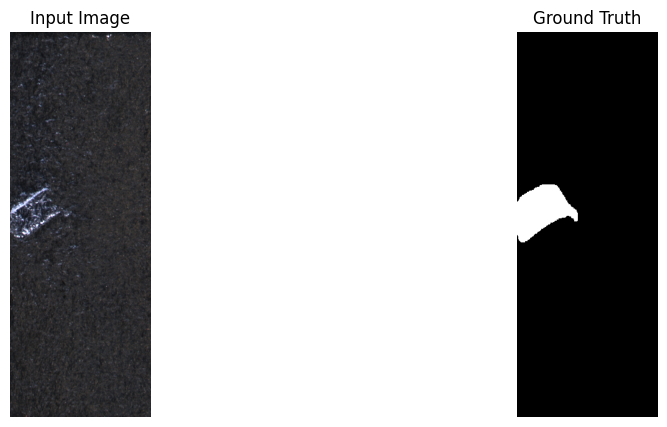

In [8]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)

plt.imshow(image)

plt.title("Input Image")
plt.axis("off")


plt.subplot(1,2,2)

plt.imshow(mask, cmap="gray")

plt.title("Ground Truth")
plt.axis("off")
plt.show()

## Image Preprocessing

In [9]:
#from inference import preprocess_image, predict_mask, resize_prediction

In [10]:
image, image_tensor = preprocess_image(image_path,DEVICE)

## Prediction

In [11]:
predicted_mask = predict_mask(model,image_tensor)

## Displaying Prediction

* First i have to resize the prediction

In [12]:
predicted_mask = resize_prediction(predicted_mask,image)

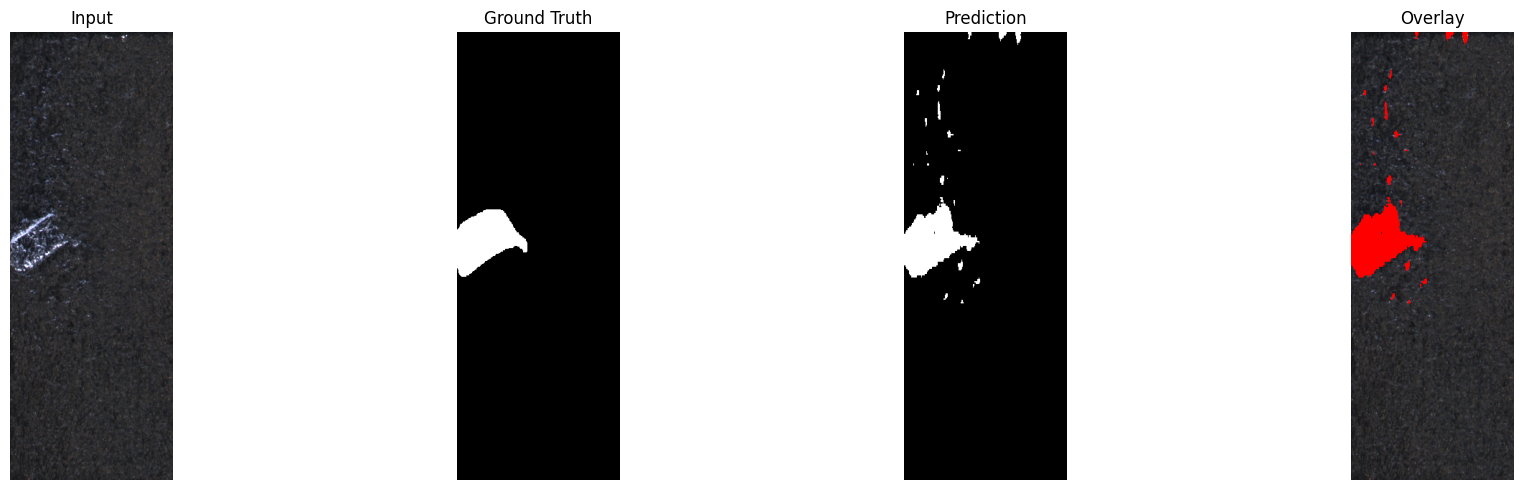

In [13]:
overlay = image.copy()

overlay[predicted_mask == 1] = [255, 0, 0]

plt.figure(figsize=(20,5))

plt.subplot(1,4,1)
plt.imshow(image)
plt.title("Input")
plt.axis("off")

plt.subplot(1,4,2)
plt.imshow(mask,cmap="gray")
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1,4,3)
plt.imshow(predicted_mask,cmap="gray")
plt.title("Prediction")
plt.axis("off")

plt.subplot(1,4,4)
plt.imshow(overlay)
plt.title("Overlay")
plt.axis("off")

plt.tight_layout()
plt.show()

# Evaluating the entire Test set

In [14]:
criterion = nn.BCEWithLogitsLoss()

In [15]:
#from utils import dice_score, iou_score

## Creating test image list

In [16]:
test_images = []

for file in os.listdir(TEST_PATH):

    if file.endswith(".png") and "_GT" not in file:

        test_images.append(file)

print(len(test_images))

1004


## Evaluating every image

In [17]:
total_test_loss = 0.0
total_dice = 0.0
total_iou = 0.0

model.eval()

with torch.no_grad():

    for image_name in test_images:

        image_path = os.path.join(TEST_PATH, image_name)
        mask_path = os.path.join(TEST_PATH,image_name.replace(".png", "_GT.png"))

        image_tensor = cv2.imread(image_path)
        image_tensor = cv2.cvtColor(image_tensor, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        image_tensor = cv2.resize(image_tensor, (256,256))
        mask = cv2.resize(mask, (256,256))

        image_tensor = image_tensor.astype(np.float32) / 255.0
        mask = mask.astype(np.float32) / 255.0

        image_tensor = torch.from_numpy(image_tensor)
        image_tensor = image_tensor.permute(2,0,1)
        image_tensor = image_tensor.unsqueeze(0)
        image_tensor = image_tensor.to(DEVICE)

        mask = torch.from_numpy(mask)
        mask = mask.unsqueeze(0)
        mask = mask.unsqueeze(0)
        mask = mask.to(DEVICE)

        outputs = model(image_tensor)

        loss = criterion(outputs, mask)
        total_test_loss += loss.item()
        total_dice += dice_score(outputs, mask)
        total_iou += iou_score(outputs, mask)

    avg_test_loss = total_test_loss / len(test_images)
    avg_dice = total_dice / len(test_images)
    avg_iou = total_iou / len(test_images)


print(f"Average Test Loss : {avg_test_loss:.4f}")

print(f"Average Dice Score: {avg_dice:.4f}")

print(f"Average IoU Score : {avg_iou:.4f}")

Average Test Loss : 0.0142
Average Dice Score: 0.3354
Average IoU Score : 0.3245
